# PSF Rotation Verification via WCS Reprojection

Validate that constructing a WCS for the PSF and reprojecting it onto the
science image grid correctly handles the rotation. For each instrument we:

1. Load the science image and its embedded PSF via `astroprism.io.load_dataset`.
2. **Rotate the PSF image** by the appropriate position angle (e.g. `PA_V3`
   for JWST, `PA_APER` for HST, `PA`/`CROTA2`/`BPA` for others) using
   `skimage.transform.rotate`.
3. Construct a WCS header for this rotated PSF: set `CDELT` from the PSF
   pixel scale, `CRVAL` to the brightest source position, `CTYPE` + **PC
   matrix** copied from the science header.
4. Use `reproject_interp` to resample the rotated PSF onto the science
   pixel grid.
5. Compare the reprojected PSF against the actual source (the AGN).

This directly follows Erik Rosolowsky's `psfreproject()` function:
[gist](https://gist.github.com/low-sky/de2159dbb8cb67de8118902b442772b4).
The key insight is that the PSF must be explicitly rotated *before*
reprojection, because the PC matrix in the science header will be applied
during reprojection as well.

### JWST MIRI position-angle keywords

| Keyword | Meaning |
|---|---|
| `PA_V3` | V3 axis position angle (used in Erik's gist) |
| `PA_APER` | Aperture position angle |

In [198]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits
from astropy.wcs import WCS
from scipy.ndimage import gaussian_filter
from reproject import reproject_interp

from astroprism.io import load_dataset

%matplotlib inline
plt.rcParams.update({"font.size": 12, "figure.dpi": 120})

## Data paths & instrument config

In [199]:
import os

DATA_ROOT = os.path.join("..", "data", "tutorial")

INSTRUMENTS = {
    "JWST_MIRI": {
        "path":       os.path.join(DATA_ROOT, "jwst_miri_cutout"),
        "loader_key": "JWST_MIRI",
        "pa_keyword": "PA_APER",
        "pa_ext":     0,
        "psf_pix_scale": 0.11,
    },
    "JWST_NIRCAM": {
        "path":       os.path.join(DATA_ROOT, "jwst_nircam"),
        "loader_key": "JWST_NIRCAM",
        "pa_keyword": "PA_APER",
        "pa_ext":     1,
        "psf_pix_scale": 0.063,
    },
}

for name, cfg in INSTRUMENTS.items():
    exists = os.path.isdir(cfg["path"])
    print(f"{name:20s}  {'OK' if exists else 'MISSING'}")

JWST_MIRI             OK
JWST_NIRCAM           OK


## Utility functions

In [200]:
def read_fits_header(dataset_path, band_name, ext):
    """Read the FITS header for a specific band."""
    fpath = os.path.join(dataset_path, f"{band_name}.fits")
    with fits.open(fpath) as hdul:
        return hdul[ext].header


def find_brightest_source(image_data, smooth_sigma=2):
    """Find brightest source after smoothing to avoid hot pixels."""
    smoothed = gaussian_filter(np.array(image_data, dtype=np.float64),
                               sigma=smooth_sigma)
    bright_y, bright_x = np.unravel_index(np.argmax(smoothed), smoothed.shape)
    print(f"  Brightest source at pixel ({bright_x}, {bright_y})")
    return bright_y, bright_x


def extract_centered_cutout(image_data, center_y, center_x, cutout_size=101):
    """Extract a cutout with bounds checking."""
    image_data = np.array(image_data)
    half = cutout_size // 2
    y0 = max(0, center_y - half)
    y1 = min(image_data.shape[0], center_y + half + 1)
    x0 = max(0, center_x - half)
    x1 = min(image_data.shape[1], center_x + half + 1)
    return image_data[y0:y1, x0:x1].copy()


def recenter_to_peak(image, manual_shift_y=0, manual_shift_x=0):
    """Shift image so peak is at center, with optional manual adjustment."""
    peak_y, peak_x = np.unravel_index(np.argmax(image), image.shape)
    cy, cx = np.array(image.shape) // 2
    dy = (cy - peak_y) + manual_shift_y
    dx = (cx - peak_x) + manual_shift_x
    shifted = np.roll(image, shift=(dy, dx), axis=(0, 1))
    print(f"  Recentering: auto=({cy-peak_y}, {cx-peak_x}), "
          f"manual=({manual_shift_y}, {manual_shift_x}), total=({dy}, {dx})")
    return shifted


def match_and_normalize(source, psf, comparison_size=None):
    """Crop to same size, normalize both to peak=1."""
    source = np.array(source, dtype=np.float64)
    psf = np.array(psf, dtype=np.float64)

    if comparison_size is None:
        comparison_size = min(source.shape[0], psf.shape[0],
                              source.shape[1], psf.shape[1])
    if comparison_size % 2 == 0:
        comparison_size -= 1
    half = comparison_size // 2

    sy, sx = np.array(source.shape) // 2
    py, px = np.array(psf.shape) // 2

    src = source[sy-half:sy+half+1, sx-half:sx+half+1]
    p   = psf[py-half:py+half+1, px-half:px+half+1]

    src = src / np.nanmax(src)
    p   = p / np.nanmax(p)

    print(f"  Comparison region: {src.shape}")
    return src, p

## PSF rotation, WCS construction & reprojection

Adapted from Erik Rosolowsky's `psfreproject()` — first rotate the PSF
image by the position angle, then build a WCS header and reproject onto
the science grid.

In [201]:
# Either works: skimage.transform.rotate or scipy.ndimage.rotate
from skimage.transform import rotate as skimage_rotate


def psf_reproject(psf_data, psf_pix_scale_arcsec,
                  ra_center, dec_center, science_header,
                  rotation_angle=0.0):
    """Rotate the PSF, construct a WCS, and reproject onto the science grid.

    Adapted from Erik Rosolowsky's psfreproject():
    https://gist.github.com/low-sky/de2159dbb8cb67de8118902b442772b4

    Steps:
      1. Rotate the PSF image by `rotation_angle` (e.g. PA_V3) using
         skimage.transform.rotate (preserves shape, uses bilinear interp).
      2. Build a tangent-plane WCS header for the rotated PSF:
         - CDELT from the PSF pixel scale
         - CRVAL at the source sky position
         - CRPIX at center of the rotated image
         - CTYPE + PC matrix copied from science header
      3. reproject_interp onto the science image grid.

    Parameters
    ----------
    psf_data : 2D array
        PSF image (e.g. from stpsf, in detector frame).
    psf_pix_scale_arcsec : float
        PSF pixel scale in arcsec.
    ra_center, dec_center : float
        Sky position to place the PSF at (degrees).
    science_header : fits.Header
        Science image header (provides target WCS + PC matrix).
    rotation_angle : float
        Angle to rotate the PSF by before reprojecting (degrees).
        In Erik's gist this is `angle + PA_V3`.
    """
    psf_data = np.array(psf_data, dtype=np.float64)

    # Step 1: rotate the PSF image
    if rotation_angle != 0.0:
        psf_rotated = skimage_rotate(psf_data, rotation_angle,
                                     resize=False, preserve_range=True)
    else:
        psf_rotated = psf_data.copy()

    ny, nx = psf_rotated.shape

    # Step 2: build WCS header for the rotated PSF
    hdr = fits.Header()
    hdr["NAXIS"]  = 2
    hdr["NAXIS1"] = int(nx)
    hdr["NAXIS2"] = int(ny)
    hdr["CRVAL1"] = float(ra_center)
    hdr["CRVAL2"] = float(dec_center)
    hdr["CRPIX1"] = float(nx / 2)
    hdr["CRPIX2"] = float(ny / 2)
    hdr["CDELT1"] = float(-psf_pix_scale_arcsec / 3600.0)
    hdr["CDELT2"] = float(psf_pix_scale_arcsec / 3600.0)
    hdr["CTYPE1"] = science_header.get("CTYPE1", "RA---TAN")
    hdr["CTYPE2"] = science_header.get("CTYPE2", "DEC--TAN")

    # Copy the PC matrix from the science header (matches Erik's gist)
    for kk in ["PC1_1", "PC1_2", "PC2_1", "PC2_2"]:
        if kk in science_header:
            hdr[kk] = float(science_header[kk])
        else:
            hdr[kk] = 0.0

    # Step 3: reproject onto science grid
    psf_hdu = fits.PrimaryHDU(psf_rotated, header=hdr)
    psf_reproj, coverage = reproject_interp(psf_hdu, science_header)
    psf_reproj[coverage == 0] = 0.0
    psf_reproj = np.nan_to_num(psf_reproj, nan=0.0)
    return psf_reproj, coverage

## Visualization (2x3 comparison, matching psf_explore.ipynb)

In [202]:
def calculate_contour_levels(image, threshold=1e-3, n_levels=5,
                             use_center_only=True,
                             min_level=None, max_level=None):
    """Logarithmically spaced contour levels (matches psf_explore.ipynb)."""
    if use_center_only:
        cy, cx = np.array(image.shape) // 2
        center_size = image.shape[0] // 2
        y_slice = slice(cy - center_size // 2, cy + center_size // 2)
        x_slice = slice(cx - center_size // 2, cx + center_size // 2)
        data = image[y_slice, x_slice]
    else:
        data = image

    positive = data[data > threshold]
    if len(positive) == 0:
        positive = data[data > 0]
    if len(positive) == 0:
        return np.logspace(-6, 0, n_levels)

    level_min = min_level if min_level is not None else positive.min()
    level_max = max_level if max_level is not None else positive.max()
    levels = np.logspace(np.log10(level_min),
                         np.log10(level_max),
                         n_levels + 1)[1:]
    return levels


def plot_comparison(src, psf, title="",
                    vmin=1e-5, vmax=1e-1, n_contours=4,
                    diff_vmin=-0.3, diff_vmax=0.3,
                    source_levels=None, psf_levels=None):
    """2x3 comparison plot (matches psf_explore.ipynb style).

    Top:    source (log)  |  PSF (log)  |  difference
    Bottom: source contours (red)  |  PSF contours (blue)  |  overlay
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    cy, cx = np.array(src.shape) // 2

    im0 = axes[0, 0].imshow(src, origin="lower",
                            norm=LogNorm(vmin=vmin, vmax=vmax))
    axes[0, 0].set_title("Bright source (normalized & centered)")
    axes[0, 0].set_xlabel("Pixels")
    axes[0, 0].set_ylabel("Pixels")
    axes[0, 0].axhline(cy, color="white", ls="--", alpha=0.5, lw=0.5)
    axes[0, 0].axvline(cx, color="white", ls="--", alpha=0.5, lw=0.5)
    plt.colorbar(im0, ax=axes[0, 0])

    im1 = axes[0, 1].imshow(psf, origin="lower",
                            norm=LogNorm(vmin=vmin, vmax=vmax))
    axes[0, 1].set_title("PSF (normalized & centered)")
    axes[0, 1].set_xlabel("Pixels")
    axes[0, 1].set_ylabel("Pixels")
    axes[0, 1].axhline(cy, color="white", ls="--", alpha=0.5, lw=0.5)
    axes[0, 1].axvline(cx, color="white", ls="--", alpha=0.5, lw=0.5)
    plt.colorbar(im1, ax=axes[0, 1])

    diff = src - psf
    im2 = axes[0, 2].imshow(diff, origin="lower", cmap="RdBu_r",
                            vmin=diff_vmin, vmax=diff_vmax)
    axes[0, 2].set_title("Difference (Source - PSF)")
    axes[0, 2].set_xlabel("Pixels")
    axes[0, 2].set_ylabel("Pixels")
    plt.colorbar(im2, ax=axes[0, 2])

    if source_levels is None:
        source_levels = calculate_contour_levels(src, n_levels=n_contours)
    if psf_levels is None:
        psf_levels = calculate_contour_levels(psf, n_levels=n_contours)

    print("Source contour levels:", source_levels)
    print("PSF contour levels:", psf_levels)

    axes[1, 0].imshow(src, origin="lower",
                      norm=LogNorm(vmin=vmin, vmax=vmax), cmap="gray")
    cs0 = axes[1, 0].contour(src, levels=source_levels,
                             colors="red", linewidths=2)
    axes[1, 0].clabel(cs0, inline=True, fontsize=8, fmt="%.1e")
    axes[1, 0].axhline(cy, color="red", ls="--", alpha=0.3, lw=0.5)
    axes[1, 0].axvline(cx, color="red", ls="--", alpha=0.3, lw=0.5)
    axes[1, 0].set_title("Source contours")

    axes[1, 1].imshow(psf, origin="lower",
                      norm=LogNorm(vmin=vmin, vmax=vmax), cmap="gray")
    cs1 = axes[1, 1].contour(psf, levels=psf_levels,
                             colors="blue", linewidths=2)
    axes[1, 1].clabel(cs1, inline=True, fontsize=8, fmt="%.1e")
    axes[1, 1].axhline(cy, color="blue", ls="--", alpha=0.3, lw=0.5)
    axes[1, 1].axvline(cx, color="blue", ls="--", alpha=0.3, lw=0.5)
    axes[1, 1].set_title("PSF contours")

    axes[1, 2].imshow(src, origin="lower",
                      norm=LogNorm(vmin=vmin, vmax=vmax), cmap="gray", alpha=0.6)
    axes[1, 2].contour(src, levels=source_levels,
                       colors="red", linewidths=2.5, linestyles="solid")
    axes[1, 2].contour(psf, levels=psf_levels,
                       colors="blue", linewidths=2.5, linestyles="dashed")
    axes[1, 2].axhline(cy, color="white", ls="--", alpha=0.3, lw=0.5)
    axes[1, 2].axvline(cx, color="white", ls="--", alpha=0.3, lw=0.5)
    axes[1, 2].set_title("Overlay (red=source, blue=PSF)")
    axes[1, 2].set_xlabel("Pixels")
    axes[1, 2].set_ylabel("Pixels")

    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Per-band comparison workflow

In [203]:
def run_comparison(data, wcs, psf, hdr, psf_pix_scale, band_label,
                   rotation_angle=0.0,
                   cutout_size=101,
                   source_stretch_exponent=2.0,
                   manual_shift_source_y=0, manual_shift_source_x=0,
                   manual_shift_psf_y=0, manual_shift_psf_x=0,
                   source_levels=None, psf_levels=None,
                   vmin=1e-5, vmax=1e-1,
                   diff_vmin=-0.3, diff_vmax=0.3):
    """Rotate PSF by angle, reproject via WCS for pixel scale, compare."""

    # Apply exponent stretch to source (same as psf_explore.ipynb)
    data_stretched = np.power(np.clip(np.array(data), 0, None),
                              source_stretch_exponent)

    bright_y, bright_x = find_brightest_source(data_stretched)
    ra_src, dec_src = wcs.pixel_to_world_values(bright_x, bright_y)

    sci_hdr = hdr.copy()
    sci_hdr["NAXIS"] = 2
    sci_hdr["NAXIS1"] = int(np.array(data).shape[1])
    sci_hdr["NAXIS2"] = int(np.array(data).shape[0])

    # Rotate PSF + reproject (identity PC → only pixel scale change)
    psf_reproj, cov = psf_reproject(
        psf, psf_pix_scale, float(ra_src), float(dec_src), sci_hdr,
        rotation_angle=rotation_angle)

    source_cut = extract_centered_cutout(data_stretched,
                                         bright_y, bright_x, cutout_size)
    psf_cut = extract_centered_cutout(psf_reproj,
                                      bright_y, bright_x, cutout_size)

    # Normalize and recenter
    src_norm = source_cut / np.nanmax(source_cut)
    psf_norm = np.clip(psf_cut, 0, None)
    psf_norm = psf_norm / np.nanmax(psf_norm)

    src_centered = recenter_to_peak(src_norm,
                                    manual_shift_source_y,
                                    manual_shift_source_x)
    psf_centered = recenter_to_peak(psf_norm,
                                    manual_shift_psf_y,
                                    manual_shift_psf_x)

    # Match sizes and plot
    src_comp, psf_comp = match_and_normalize(src_centered, psf_centered)

    # --- Zoomed WCS view ---
    from astropy.wcs import WCS as _WCS
    sci_wcs = _WCS(sci_hdr)

    zoom = 120
    y0 = max(0, bright_y - zoom)
    y1 = min(data_stretched.shape[0], bright_y + zoom)
    x0 = max(0, bright_x - zoom)
    x1 = min(data_stretched.shape[1], bright_x + zoom)
    slices = (slice(y0, y1), slice(x0, x1))
    cutout_wcs = sci_wcs[slices]

    fig = plt.figure(figsize=(18, 5))

    ax1 = fig.add_subplot(1, 3, 1, projection=cutout_wcs)
    ax1.imshow(data_stretched[slices], origin="lower",
               norm=LogNorm(vmin=np.nanpercentile(data_stretched[data_stretched > 0], 1),
                            vmax=np.nanpercentile(data_stretched, 99.9)))
    ax1.set_title("Science image")
    ax1.coords["ra"].set_axislabel("RA")
    ax1.coords["dec"].set_axislabel("Dec")

    ax2 = fig.add_subplot(1, 3, 2, projection=cutout_wcs)
    psf_pos = psf_reproj.copy()
    psf_pos[psf_pos <= 0] = np.nan
    ax2.imshow(psf_pos[slices], origin="lower",
               norm=LogNorm(vmin=np.nanmin(psf_pos[np.isfinite(psf_pos)]),
                            vmax=np.nanmax(psf_pos)))
    ax2.set_title("Reprojected PSF (same WCS grid)")
    ax2.coords["ra"].set_axislabel("RA")
    ax2.coords["dec"].set_axislabel("Dec")

    ax3 = fig.add_subplot(1, 3, 3, projection=cutout_wcs)
    ax3.imshow(data_stretched[slices], origin="lower",
               norm=LogNorm(vmin=np.nanpercentile(data_stretched[data_stretched > 0], 1),
                            vmax=np.nanpercentile(data_stretched, 99.9)),
               cmap="gray", alpha=0.7)
    psf_zoom = psf_reproj[slices]
    psf_zoom_norm = psf_zoom / psf_zoom.max() if psf_zoom.max() > 0 else psf_zoom
    ax3.contour(psf_zoom_norm, levels=[0.01, 0.05, 0.1, 0.3, 0.5],
                colors="cyan", linewidths=1.5,
                transform=ax3.get_transform("pixel"))
    ax3.set_title("Overlay (cyan = PSF contours)")
    ax3.coords["ra"].set_axislabel("RA")
    ax3.coords["dec"].set_axislabel("Dec")

    fig.suptitle(f"{band_label} — WCS view", fontweight="bold")
    plt.tight_layout()
    plt.show()

    # --- Normalized cutout comparison ---
    plot_comparison(src_comp, psf_comp, title=band_label,
                    vmin=vmin, vmax=vmax,
                    diff_vmin=diff_vmin, diff_vmax=diff_vmax,
                    source_levels=source_levels, psf_levels=psf_levels)

    return src_comp, psf_comp

## Verification: angle sweep

To check that the header PA is actually correct, we sweep over a range
of rotation angles and measure how well the reprojected PSF matches the
source at each angle. The best angle should coincide with the header value.

Metrics:
- **Core residual**: mean absolute difference in the central pixels
  (lower = better alignment).
- **Cross-correlation**: normalised peak of cross-correlation
  (higher = better alignment).

In [204]:
from scipy.signal import fftconvolve


def alignment_metric(src, psf_rot, core_frac=0.3):
    """Compute alignment quality between source and PSF cutouts.

    Returns (core_residual, xcorr_peak) where lower residual and
    higher xcorr_peak both indicate better alignment.
    """
    ny, nx = src.shape
    cy, cx = ny // 2, nx // 2
    r = int(min(ny, nx) * core_frac / 2)

    s = src[cy-r:cy+r+1, cx-r:cx+r+1]
    p = psf_rot[cy-r:cy+r+1, cx-r:cx+r+1]

    residual = np.mean(np.abs(s - p))

    # Normalised cross-correlation
    s_z = s - s.mean()
    p_z = p - p.mean()
    denom = np.sqrt(np.sum(s_z**2) * np.sum(p_z**2))
    if denom == 0:
        xcorr = 0.0
    else:
        cc = fftconvolve(s_z, p_z[::-1, ::-1], mode="full")
        xcorr = cc.max() / denom

    return residual, xcorr


def sweep_angles(data, wcs_obj, psf, hdr, psf_pix_scale,
                 nominal_angle, band_label,
                 angle_range=(-30, 30), n_angles=31,
                 cutout_size=101):
    """Sweep rotation angles and plot alignment quality vs angle.

    Tests angles from (nominal + angle_range[0]) to (nominal + angle_range[1]).
    Plots the residual and cross-correlation curves with the nominal angle
    marked, so you can visually confirm it sits at the optimum.
    """
    angles = np.linspace(nominal_angle + angle_range[0],
                         nominal_angle + angle_range[1], n_angles)

    bright_y, bright_x = find_brightest_source(data)
    ra_src, dec_src = wcs_obj.pixel_to_world_values(bright_x, bright_y)

    sci_hdr = hdr.copy()
    sci_hdr["NAXIS"] = 2
    sci_hdr["NAXIS1"] = int(np.array(data).shape[1])
    sci_hdr["NAXIS2"] = int(np.array(data).shape[0])

    # Prepare source cutout (fixed across sweep)
    source_cut = extract_centered_cutout(np.array(data),
                                         bright_y, bright_x, cutout_size)
    src_norm = source_cut / np.nanmax(source_cut)
    src_centered = recenter_to_peak(src_norm)

    residuals = []
    xcorrs = []

    for ang in angles:
        psf_reproj, _ = psf_reproject(
            psf, psf_pix_scale, float(ra_src), float(dec_src), sci_hdr,
            rotation_angle=ang)
        psf_cut = extract_centered_cutout(psf_reproj,
                                          bright_y, bright_x, cutout_size)
        psf_norm = np.clip(psf_cut, 0, None)
        if np.nanmax(psf_norm) > 0:
            psf_norm = psf_norm / np.nanmax(psf_norm)
        psf_c = recenter_to_peak(psf_norm)

        s, p = match_and_normalize(src_centered, psf_c)
        res, xc = alignment_metric(s, p)
        residuals.append(res)
        xcorrs.append(xc)

    residuals = np.array(residuals)
    xcorrs = np.array(xcorrs)

    best_res_angle = angles[np.argmin(residuals)]
    best_xc_angle  = angles[np.argmax(xcorrs)]

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(angles, residuals, "o-", color="steelblue", ms=4)
    ax1.axvline(nominal_angle, color="red", ls="--", lw=1.5,
                label=f"Header PA = {nominal_angle:.1f}°")
    ax1.axvline(best_res_angle, color="green", ls=":", lw=1.5,
                label=f"Best fit = {best_res_angle:.1f}°")
    ax1.set_xlabel("Rotation angle (deg)")
    ax1.set_ylabel("Core residual (lower = better)")
    ax1.legend(fontsize=9)
    ax1.set_title("Residual vs angle")

    ax2.plot(angles, xcorrs, "o-", color="darkorange", ms=4)
    ax2.axvline(nominal_angle, color="red", ls="--", lw=1.5,
                label=f"Header PA = {nominal_angle:.1f}°")
    ax2.axvline(best_xc_angle, color="green", ls=":", lw=1.5,
                label=f"Best fit = {best_xc_angle:.1f}°")
    ax2.set_xlabel("Rotation angle (deg)")
    ax2.set_ylabel("Cross-correlation (higher = better)")
    ax2.legend(fontsize=9)
    ax2.set_title("Cross-correlation vs angle")

    fig.suptitle(f"{band_label}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"  Header PA:     {nominal_angle:.2f}°")
    print(f"  Best residual: {best_res_angle:.2f}° (Δ = {best_res_angle - nominal_angle:+.2f}°)")
    print(f"  Best xcorr:    {best_xc_angle:.2f}° (Δ = {best_xc_angle - nominal_angle:+.2f}°)")

    return angles, residuals, xcorrs

---

## JWST MIRI (F770W, F1000W, F1130W, F2100W)

`stpsf`-generated PSFs are in a fixed detector frame. The science image PC
matrix encodes the rotation from detector to sky. By copying it into the
PSF header, `reproject` handles the rotation automatically.

PA_APER per band:
  F1000W_full           PA_APER=358.5593  PA_V3=353.5624
  F1130W_full           PA_APER=358.5594  PA_V3=353.5625
  F2100W_full           PA_APER=358.5593  PA_V3=353.5625 <--
  F770W_full            PA_APER=358.5592  PA_V3=353.5624

Running F2100W_full  PA_V3=353.56  PA_APER=358.56
  rotation = angle(-6.5) + PA_V3(353.56) = 347.06°


Set DATE-AVG to '2022-11-22T11:13:46.663' from MJD-AVG.
Set DATE-END to '2022-11-22T12:45:18.269' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.730609 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564059865.393 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-22T11:22:53.021' from MJD-AVG.
Set DATE-END to '2022-11-22T12:57:19.804' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.727539 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564098702.386 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-22T11:37:30.642' from MJD-AVG.
Set DATE-END to '2022-11-22T13:10:05.691' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.723355 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564151617.100 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  Brightest source at pixel (443, 242)
  Recentering: auto=(0, 0), manual=(-3, -1), total=(-3, -1)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)


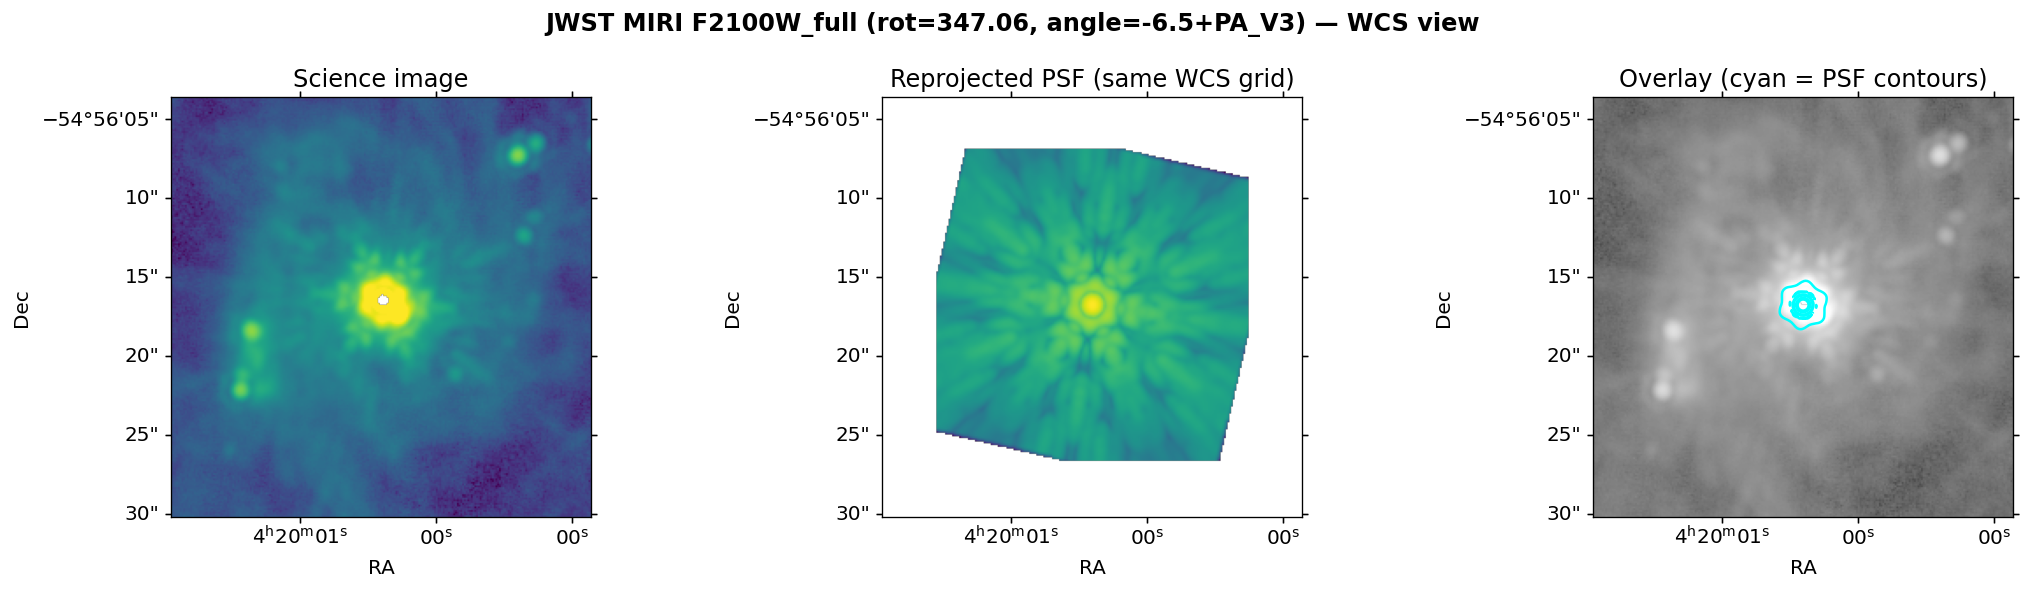

Source contour levels: [2e-05, 5e-05, 7e-05, 0.0001, 0.001, 0.01]
PSF contour levels: [1e-20, 0.001, 0.01, 0.1]


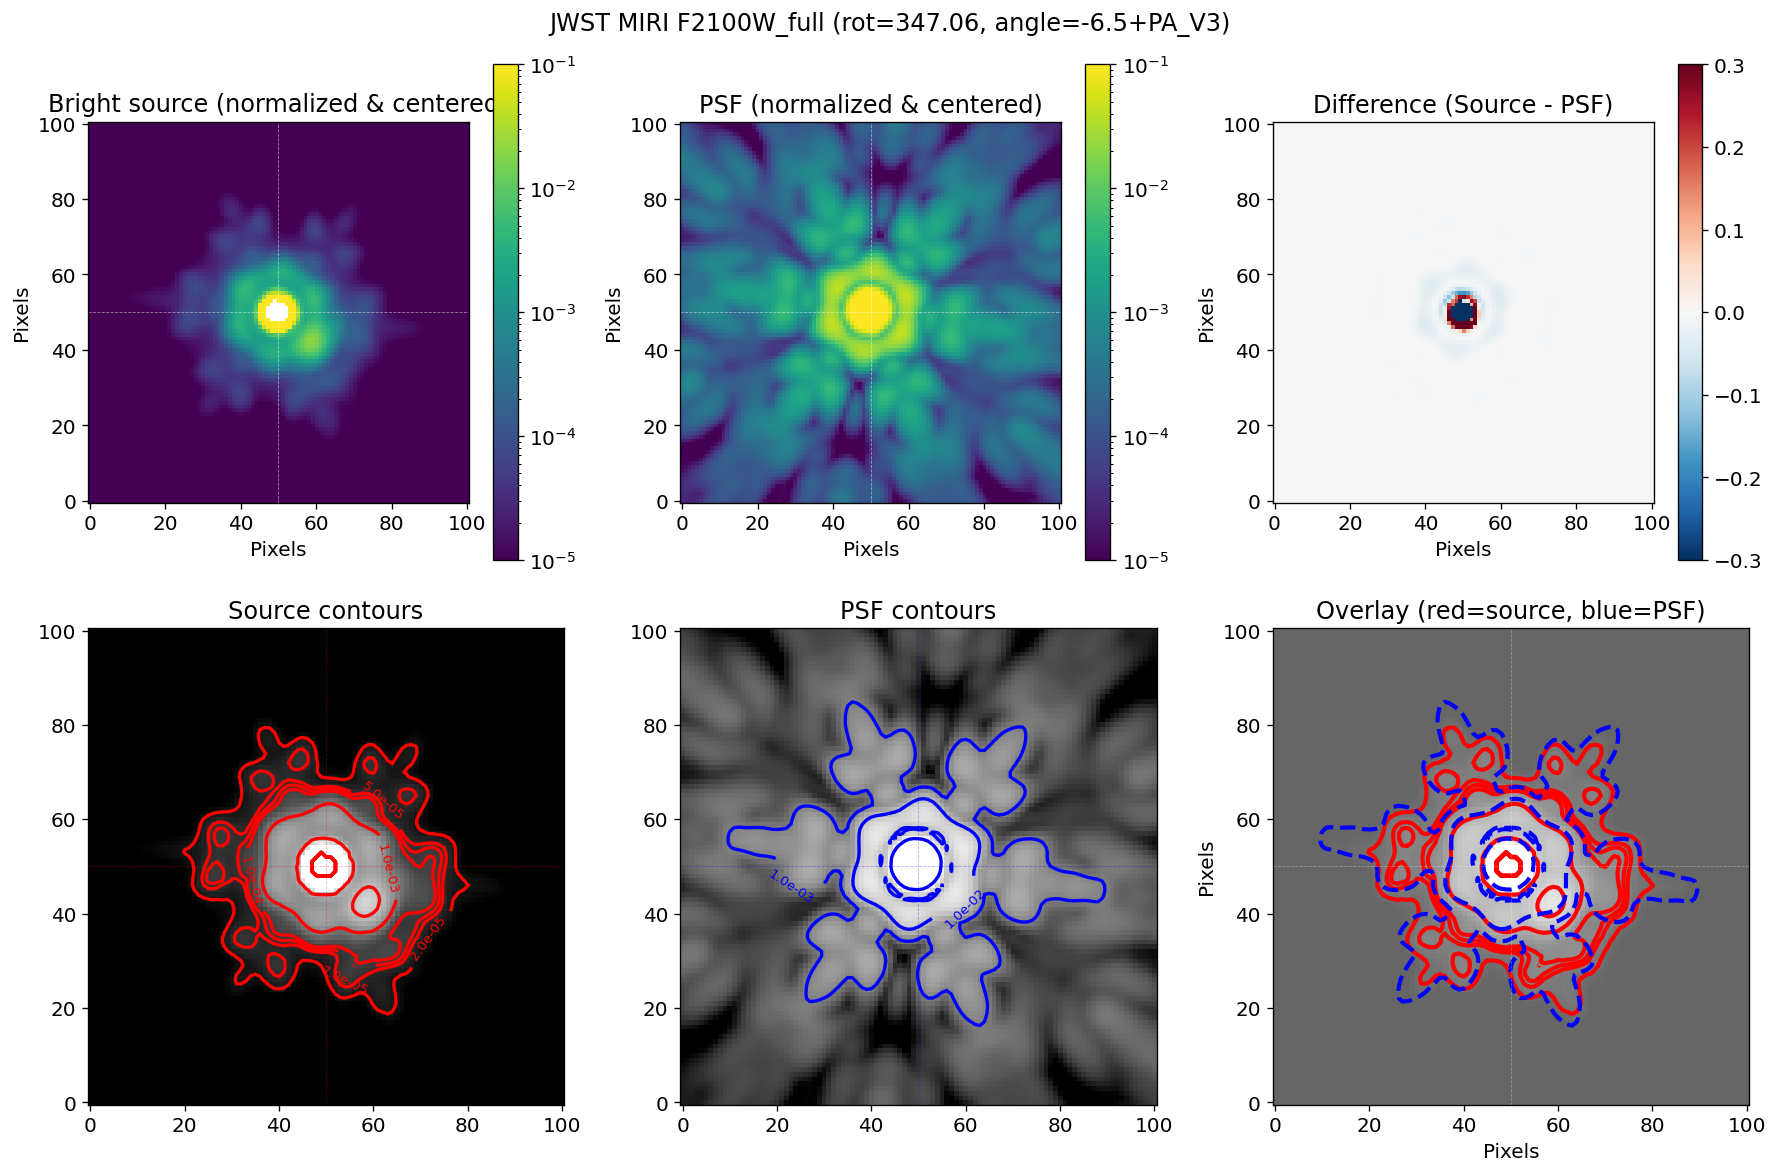

  Brightest source at pixel (444, 242)
  Recentering: auto=(0, 1), manual=(0, 0), total=(0, 1)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)


Set DATE-AVG to '2022-11-22T11:37:30.642' from MJD-AVG.
Set DATE-END to '2022-11-22T13:10:05.691' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.723355 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564151617.100 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recenterin

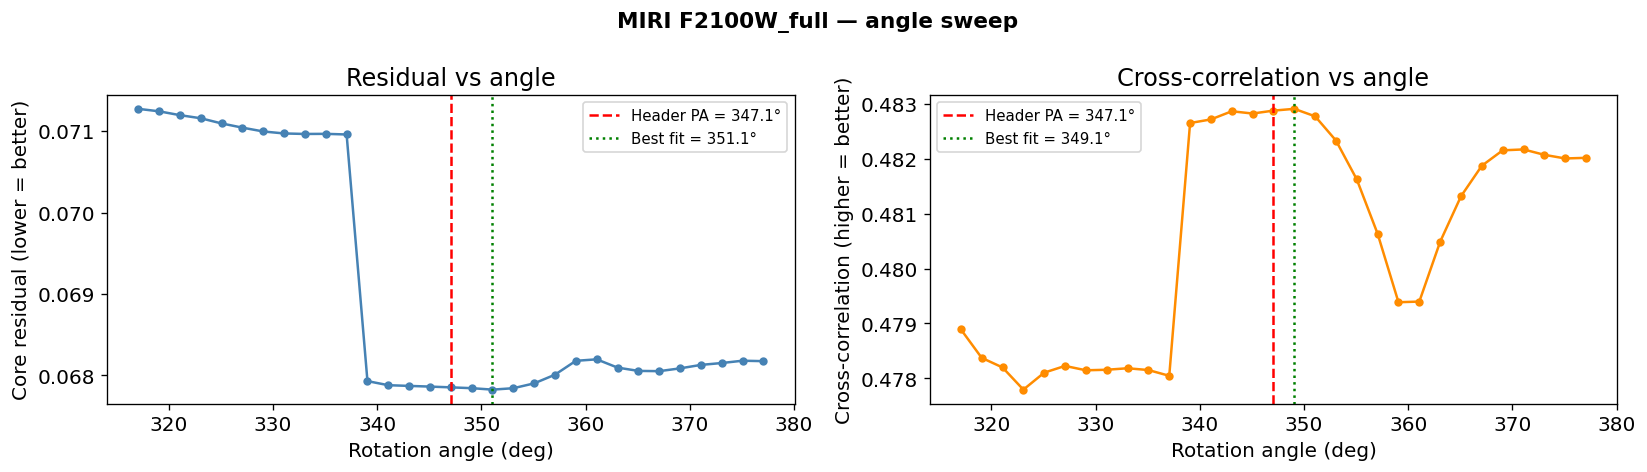

  Header PA:     347.06°
  Best residual: 351.06° (Δ = +4.00°)
  Best xcorr:    349.06° (Δ = +2.00°)


In [205]:
cfg = INSTRUMENTS["JWST_MIRI"]
dataset = load_dataset(path=cfg["path"], instrument=cfg["loader_key"])

# Focus on F2100W first (same band as psf_explore.ipynb)
TARGET_BAND = "f2100w"

print("PA_APER per band:")
for key in dataset.channel_keys:
    h = read_fits_header(cfg["path"], key, cfg["pa_ext"])
    marker = " <--" if TARGET_BAND in key.lower() else ""
    print(f"  {key:20s}  PA_APER={h['PA_APER']:.4f}  PA_V3={h['PA_V3']:.4f}{marker}")

for key in dataset.channel_keys:
    if TARGET_BAND not in key.lower():
        continue
    data, wcs, psf = dataset[key]
    hdr = read_fits_header(cfg["path"], key, cfg["pa_ext"])
    pa_v3 = hdr.get("PA_V3", 0.0)
    pa_aper = hdr.get("PA_APER", 0.0)
    print(f"\nRunning {key}  PA_V3={pa_v3:.2f}  PA_APER={pa_aper:.2f}")

    # Erik's formula: angle + PA_V3  (angle is a small correction)
    angle_correction = -6.5  # Erik's initial guess; set to 0 to test pure PA_V3
    rot_angle = angle_correction + pa_v3
    print(f"  rotation = angle({angle_correction}) + PA_V3({pa_v3:.2f}) = {rot_angle:.2f}°")
    run_comparison(data, wcs, psf, hdr, cfg["psf_pix_scale"],
                   rotation_angle=rot_angle,
                   manual_shift_source_y=-3, manual_shift_source_x=-1,
                   source_levels=[2e-5, 5e-5, 7e-5, 1e-4, 1e-3, 1e-2],
                   psf_levels=[1e-20, 1e-3, 1e-2, 1e-1],
                   band_label=f"JWST MIRI {key} (rot={rot_angle:.2f}, angle={angle_correction}+PA_V3)")
    sweep_angles(data, wcs, psf, hdr, cfg["psf_pix_scale"],
                 nominal_angle=rot_angle,
                 band_label=f"MIRI {key} — angle sweep")

---

## JWST MIRI F770W

Shorter wavelength — different diffraction pattern, same PA_V3.
The `angle_correction` should be the same if it's an instrument constant.

Running F770W_full  PA_V3=353.56  PA_APER=358.56
  rotation = angle(-6.5) + PA_V3(353.56) = 347.06°
  Brightest source at pixel (444, 244)
  Recentering: auto=(0, -1), manual=(0, 2), total=(0, 1)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)


Set DATE-AVG to '2022-11-22T11:04:08.058' from MJD-AVG.
Set DATE-END to '2022-11-22T12:35:32.733' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.733757 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564020048.840 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


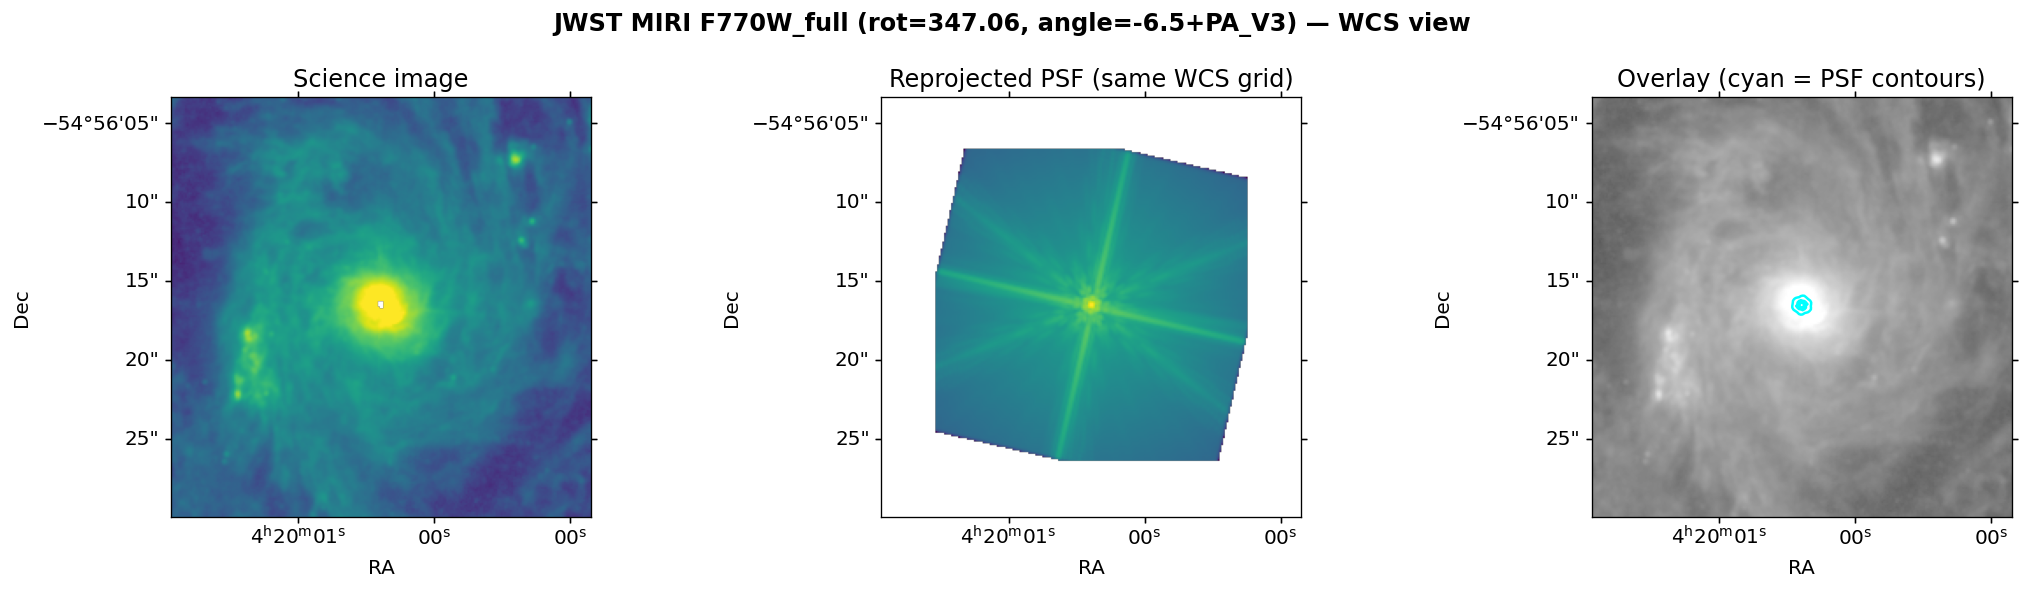

Source contour levels: [5e-05, 0.0001, 0.0005, 0.001, 0.01]
PSF contour levels: [0.001, 0.01, 0.1]


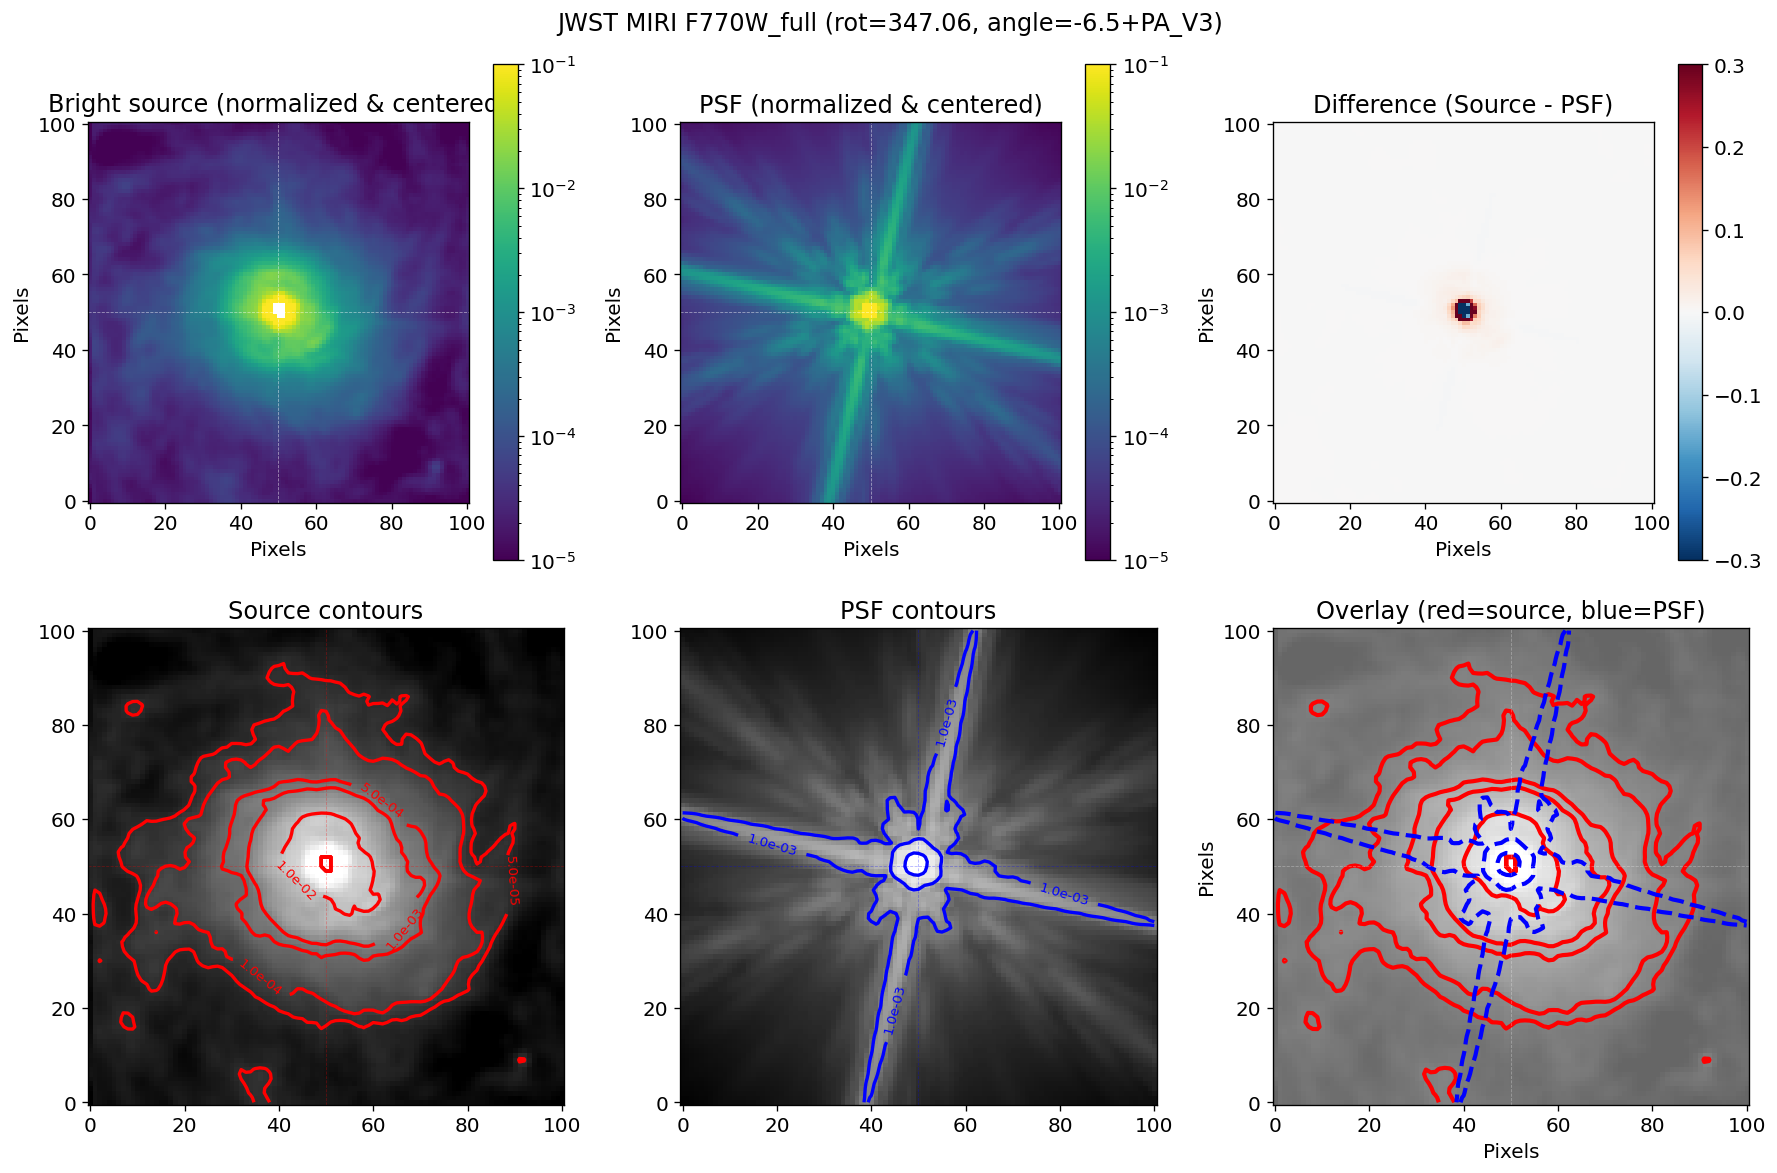

  Brightest source at pixel (445, 244)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)


Set DATE-AVG to '2022-11-22T11:04:08.058' from MJD-AVG.
Set DATE-END to '2022-11-22T12:35:32.733' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.733757 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564020048.840 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Comparison region: (101, 101)
  Recentering: auto=(0, 0), ma

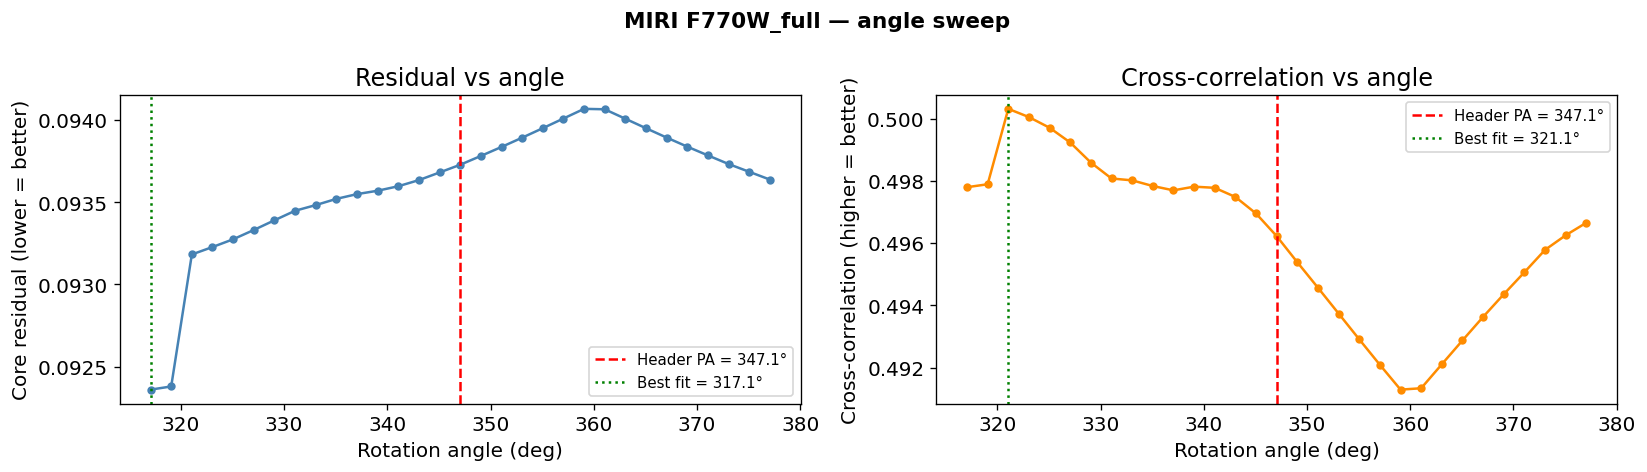

  Header PA:     347.06°
  Best residual: 317.06° (Δ = -30.00°)
  Best xcorr:    321.06° (Δ = -26.00°)


In [206]:
TARGET_BAND_2 = "f770w"

for key in dataset.channel_keys:
    if TARGET_BAND_2 not in key.lower():
        continue
    data, wcs, psf = dataset[key]
    hdr = read_fits_header(cfg["path"], key, cfg["pa_ext"])
    pa_v3 = hdr.get("PA_V3", 0.0)
    pa_aper = hdr.get("PA_APER", 0.0)
    print(f"Running {key}  PA_V3={pa_v3:.2f}  PA_APER={pa_aper:.2f}")

    angle_correction = -6.5
    rot_angle = angle_correction + pa_v3
    print(f"  rotation = angle({angle_correction}) + PA_V3({pa_v3:.2f}) = {rot_angle:.2f}°")
    run_comparison(data, wcs, psf, hdr, cfg["psf_pix_scale"],
                   rotation_angle=rot_angle,
                   source_stretch_exponent=2.0,
                   manual_shift_source_y=0, manual_shift_source_x=2,
                   source_levels=[5e-5, 1e-4, 5e-4, 1e-3, 1e-2],
                   psf_levels=[1e-3, 1e-2, 1e-1],
                   band_label=f"JWST MIRI {key} (rot={rot_angle:.2f}, angle={angle_correction}+PA_V3)")
    sweep_angles(data, wcs, psf, hdr, cfg["psf_pix_scale"],
                 nominal_angle=rot_angle,
                 band_label=f"MIRI {key} — angle sweep")

---

## JWST NIRCam F300M

NIRCam long-wavelength channel (0.063"/pix). Sharp diffraction spikes —
PSF structure should be very visible in the source.

Set DATE-AVG to '2022-11-22T14:25:43.879' from MJD-AVG.
Set DATE-END to '2022-11-22T15:25:15.123' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.657299 from OBSGEO-[XYZ].
Set OBSGEO-H to 1564986906.933 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-22T14:31:58.338' from MJD-AVG.
Set DATE-END to '2022-11-22T15:09:30.228' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.648630 from OBSGEO-[XYZ].
Set OBSGEO-H to 1565096508.898 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-22T14:47:48.577' from MJD-AVG.
Set DATE-END to '2022-11-22T15:25:15.123' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.643309 from OBSGEO-[XYZ].
Set OBSGEO-H to 1565163771.514 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-22T14:11:34.309' from MJD-AVG.
Set DATE-END to '2022-11-22T14:54:17.589' from MJD-END'. [astropy.wcs.wcs]


PA per band:
  jwst_nircam_ngc1566_f200w  PA_APER=354.3356  PA_V3=353.9615
  jwst_nircam_ngc1566_f300m  PA_APER=354.0057  PA_V3=353.9615 <--
  jwst_nircam_ngc1566_f335m  PA_APER=354.0057  PA_V3=353.9616
  jwst_nircam_ngc1566_f360m  PA_APER=354.0056  PA_V3=353.9615

Running jwst_nircam_ngc1566_f300m  PA_V3=353.96  PA_APER=354.01
  rotation = angle(0.0) + PA_V3(353.96) = 353.96°
  Brightest source at pixel (864, 891)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)


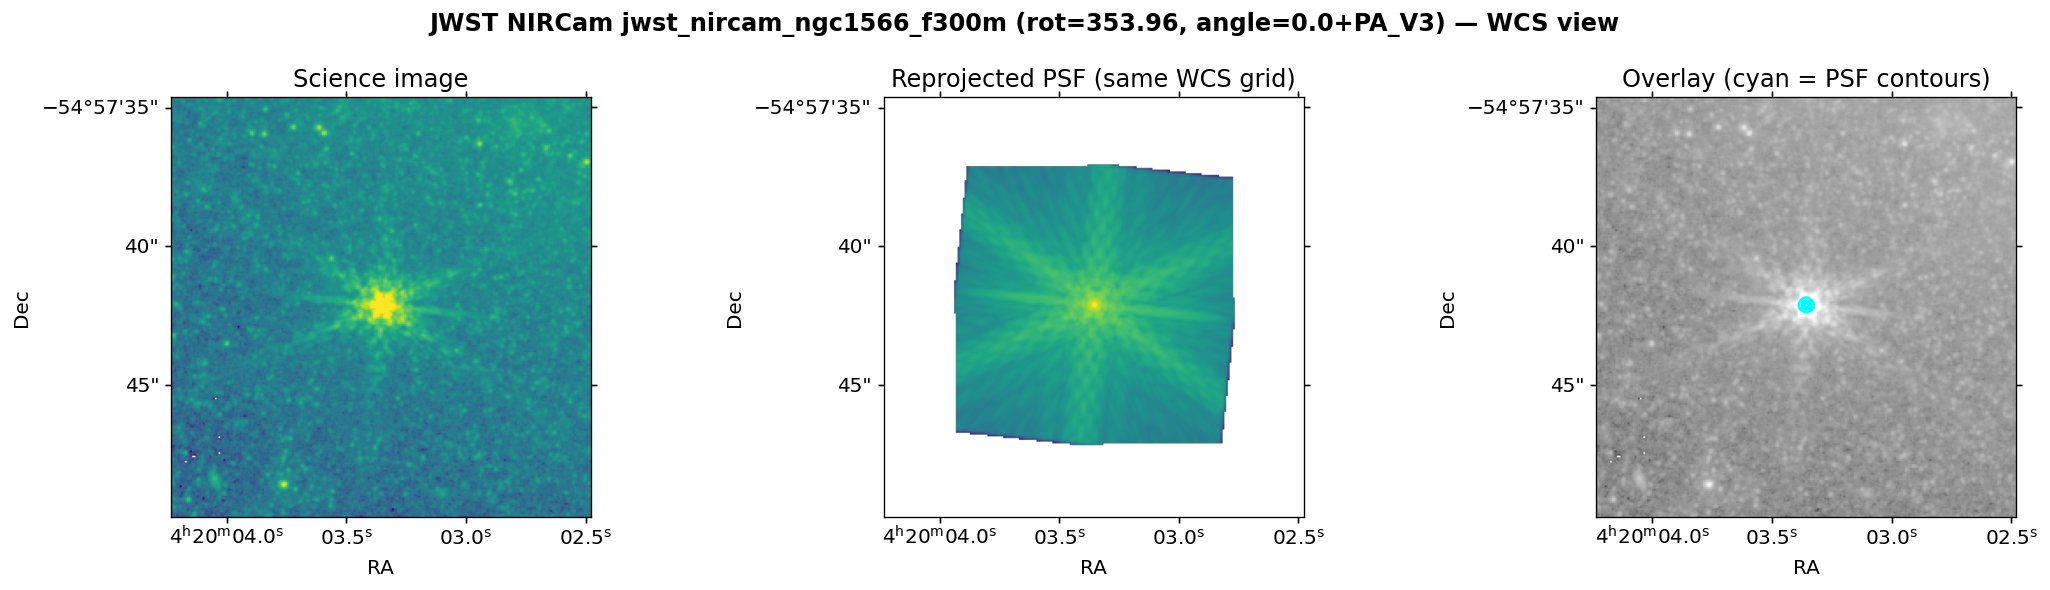

Source contour levels: [2e-05, 5e-05, 7e-05, 0.0001, 0.001, 0.01]
PSF contour levels: [0.001, 0.01, 0.1]


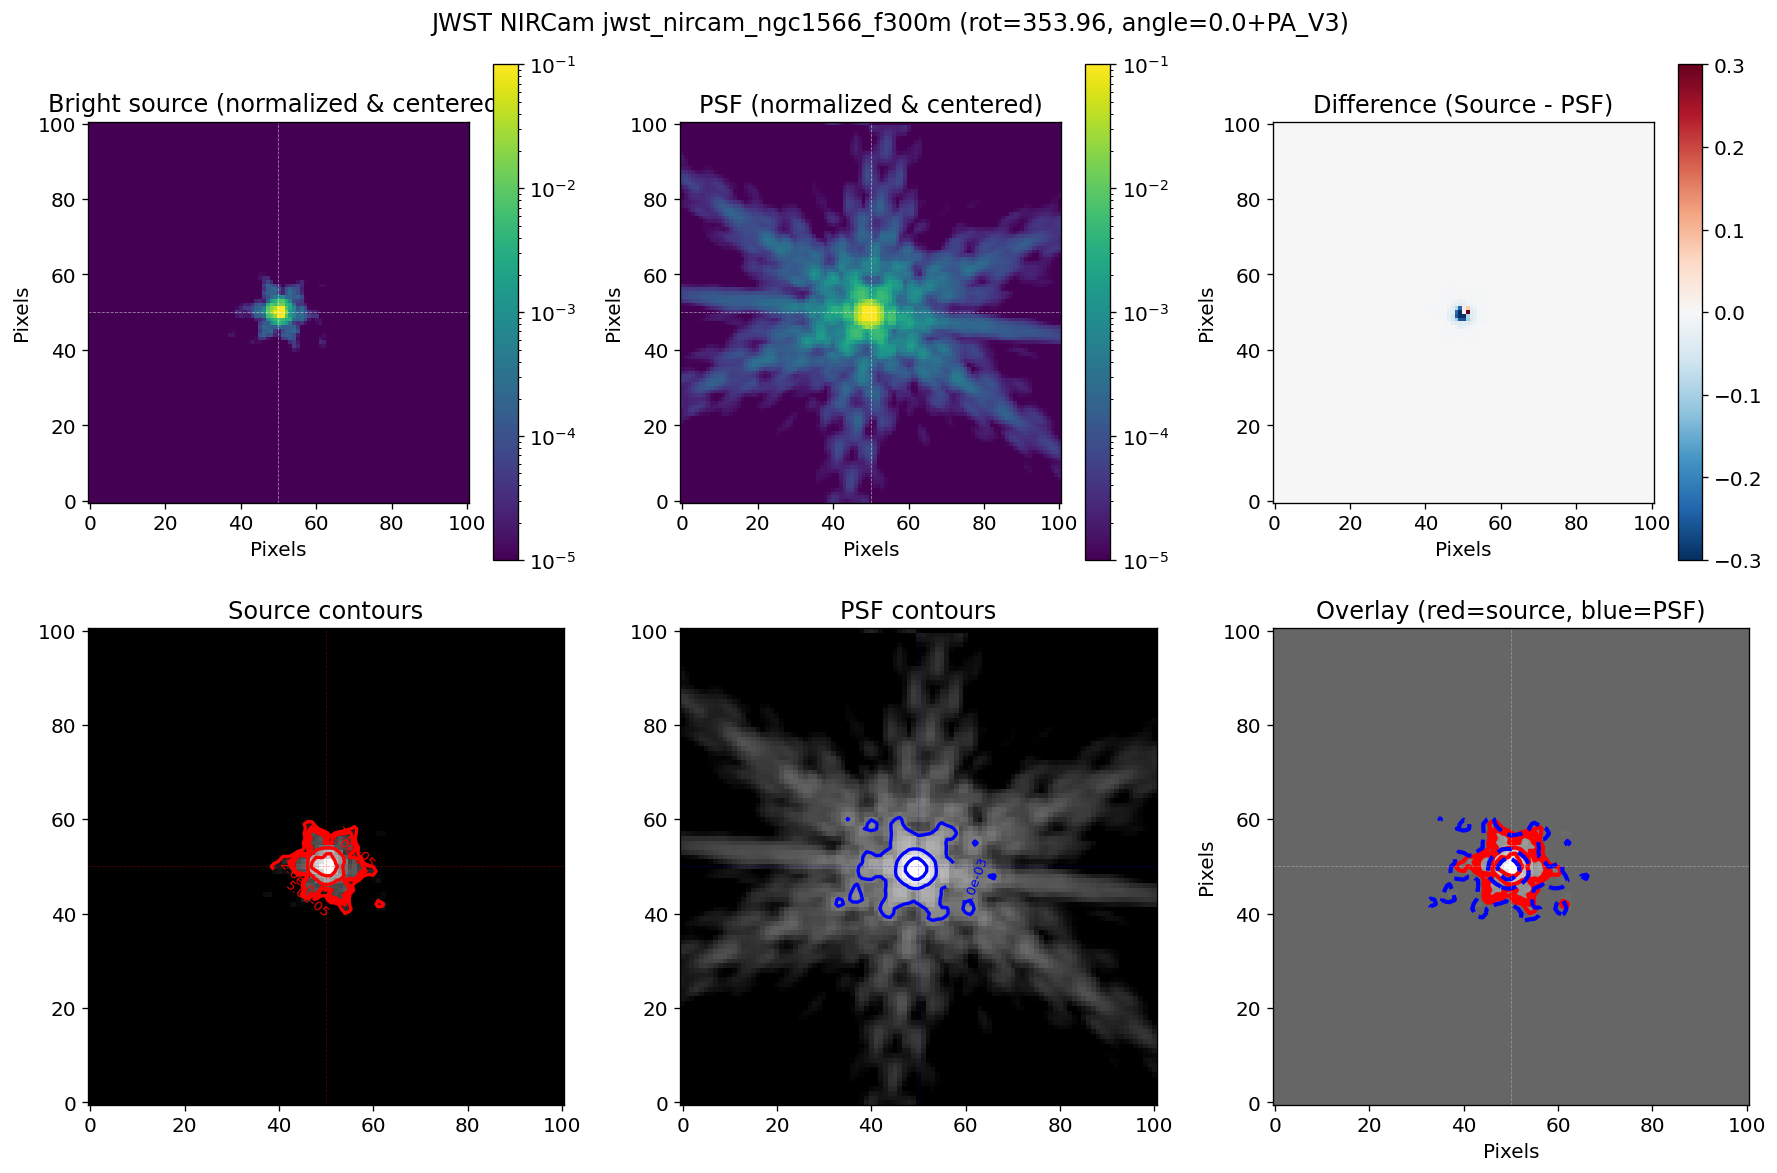

  Brightest source at pixel (864, 891)
  Recentering: auto=(0, 0), manual=(0, 0), total=(0, 0)


Set DATE-AVG to '2022-11-22T14:31:58.338' from MJD-AVG.
Set DATE-END to '2022-11-22T15:09:30.228' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.648630 from OBSGEO-[XYZ].
Set OBSGEO-H to 1565096508.898 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recentering: auto=(-1, 0), manual=(0, 0), total=(-1, 0)
  Comparison region: (101, 101)
  Recenter

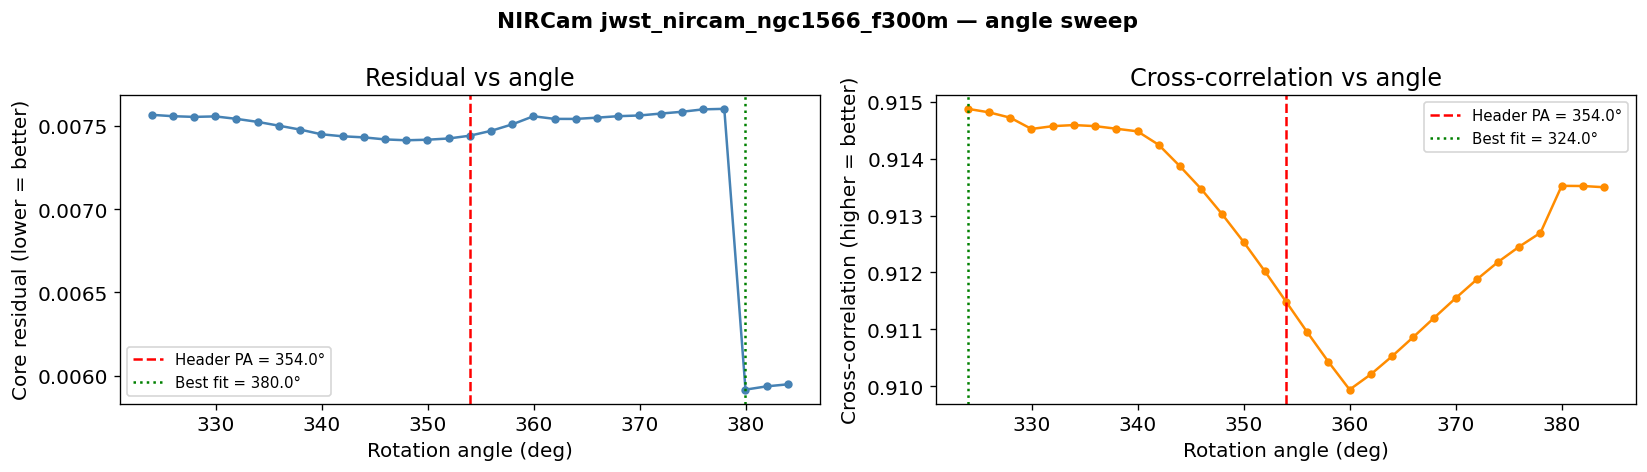

  Header PA:     353.96°
  Best residual: 379.96° (Δ = +26.00°)
  Best xcorr:    323.96° (Δ = -30.00°)


In [207]:
cfg_nc = INSTRUMENTS["JWST_NIRCAM"]
dataset_nc = load_dataset(path=cfg_nc["path"], instrument=cfg_nc["loader_key"])

TARGET_BAND_NC = "f300m"

print("PA per band:")
for key in dataset_nc.channel_keys:
    h = read_fits_header(cfg_nc["path"], key, cfg_nc["pa_ext"])
    marker = " <--" if TARGET_BAND_NC in key.lower() else ""
    print(f"  {key:20s}  PA_APER={h['PA_APER']:.4f}  PA_V3={h['PA_V3']:.4f}{marker}")

for key in dataset_nc.channel_keys:
    if TARGET_BAND_NC not in key.lower():
        continue
    data, wcs, psf = dataset_nc[key]
    hdr = read_fits_header(cfg_nc["path"], key, cfg_nc["pa_ext"])
    pa_v3 = hdr.get("PA_V3", 0.0)
    pa_aper = hdr.get("PA_APER", 0.0)
    print(f"\nRunning {key}  PA_V3={pa_v3:.2f}  PA_APER={pa_aper:.2f}")

    angle_correction = 0.0  # start with 0 for NIRCam — may differ from MIRI
    rot_angle = angle_correction + pa_v3
    
    print(f"  rotation = angle({angle_correction}) + PA_V3({pa_v3:.2f}) = {rot_angle:.2f}°")
    run_comparison(data, wcs, psf, hdr, cfg_nc["psf_pix_scale"],
                   rotation_angle=rot_angle,
                   source_levels=[2e-5, 5e-5, 7e-5, 1e-4, 1e-3, 1e-2],
                   psf_levels=[1e-3, 1e-2, 1e-1],
                   band_label=f"JWST NIRCam {key} (rot={rot_angle:.2f}, angle={angle_correction}+PA_V3)")
    sweep_angles(data, wcs, psf, hdr, cfg_nc["psf_pix_scale"],
                 nominal_angle=rot_angle,
                 band_label=f"NIRCam {key} — angle sweep")

---

## Conclusions & next steps

This notebook follows Erik Rosolowsky's `psfreproject()` approach:
rotate the PSF by `PA_V3`, build a WCS header, and let
`reproject_interp` handle the pixel-scale resampling.

Check the results:

1. **Overlay panel (bottom right)**: do the red (source) and blue (PSF)
   contours align? If yes, the rotation is correct.
2. **Difference image (top right)**: close to zero in the core means good
   alignment. Residuals in the wings are expected (galaxy emission).
3. **Angle sweep**: does the minimum residual / maximum cross-correlation
   coincide with the header `PA_V3` value?

### Once MIRI works

- [ ] Add NIRCam, HST, Spitzer, Herschel, Astrosat sections back
- [ ] Integrate into `instrument_loaders.py`
- [ ] Consider adopting this in `Convolver` for production